# Constructive Closure Demo

This notebook demonstrates how to compute a constructive closure $\langle B \rangle_A$, a minimum constructive generating subset $B$, and the invariant $s(A)$ for a central arrangement.

Use the **SageMath** kernel for this notebook.

In [1]:
import sys
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sage.all import QQ, matrix, vector

root = Path.cwd()
src = root / "src"
if src.exists() and str(src) not in sys.path:
    sys.path.insert(0, str(src))

from hyperplane_arrangements import (
    HyperplaneArrangement,
    constructive_closure,
    minimal_constructive_subset,
    s,
)

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [ ]:
def segment_from_row(row, xlim, ylim):
    a, b, c = [float(x) for x in row]
    eps = 1e-9
    points = []

    if abs(a) < eps and abs(b) < eps:
        return None

    for x in xlim:
        if abs(b) >= eps:
            y = (-c - a * x) / b
            if ylim[0] - eps <= y <= ylim[1] + eps:
                points.append((x, y))

    for y in ylim:
        if abs(a) >= eps:
            x = (-c - b * y) / a
            if xlim[0] - eps <= x <= xlim[1] + eps:
                points.append((x, y))

    unique = []
    for point in points:
        rounded = (round(point[0], 10), round(point[1], 10))
        if rounded not in [(round(p[0], 10), round(p[1], 10)) for p in unique]:
            unique.append(point)

    if len(unique) < 2:
        return None
    return unique[0], unique[1]


def affine_intersection(row1, row2):
    system = matrix(QQ, [[row1[0], row1[1]], [row2[0], row2[1]]])
    if system.det() == 0:
        return None
    rhs = vector(QQ, [-row1[2], -row2[2]])
    sol = system.solve_right(rhs)
    return float(sol[0]), float(sol[1])


def hyperplanes_through_flat(A, indices):
    submat = A.mat[list(indices), :]
    if submat.rank() != A.n - 1:
        return tuple()
    row_space = submat.row_space()
    return tuple(i for i, row in enumerate(A.mat.rows()) if row in row_space)


def constructive_points(A, subset_indices):
    points = []
    seen = set()
    for flat in combinations(sorted(subset_indices), A.n - 1):
        carriers = hyperplanes_through_flat(A, flat)
        if len(carriers) <= len(flat):
            continue
        point = affine_intersection(A.mat[flat[0]], A.mat[flat[1]])
        if point is None:
            continue
        rounded = (round(point[0], 8), round(point[1], 8))
        if rounded not in seen:
            points.append((point, flat, carriers))
            seen.add(rounded)
    return points


def plot_constructive_state(A, subset_indices, ax, title, xlim=(-0.5, 2.5), ylim=(-0.5, 2.5)):
    subset_indices = tuple(sorted(subset_indices))
    closure_indices = set(A.constructive_closure_indices(subset_indices))
    subset_set = set(subset_indices)
    added = closure_indices - subset_set

    for i, row in enumerate(A.mat.rows()):
        segment = segment_from_row(row, xlim, ylim)
        if segment is None:
            continue

        if i in subset_set:
            style = dict(color="#1f77b4", linewidth=3.0, alpha=0.95)
        elif i in added:
            style = dict(color="#ff7f0e", linewidth=3.0, alpha=0.95)
        else:
            style = dict(color="#c7c7c7", linewidth=1.5, alpha=0.9, linestyle="--")

        xs = [segment[0][0], segment[1][0]]
        ys = [segment[0][1], segment[1][1]]
        ax.plot(xs, ys, **style)

        mx = 0.5 * (xs[0] + xs[1])
        my = 0.5 * (ys[0] + ys[1])
        ax.text(mx, my, f"H{i}", fontsize=10, ha="center", va="center", backgroundcolor="white")

    for point, flat, carriers in constructive_points(A, subset_indices):
        if xlim[0] <= point[0] <= xlim[1] and ylim[0] <= point[1] <= ylim[1]:
            ax.scatter([point[0]], [point[1]], color="black", s=35, zorder=10)
            ax.annotate(
                f"flat {flat} -> {carriers}",
                point,
                xytext=(8, 8),
                textcoords="offset points",
                fontsize=9,
            )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)
    ax.set_title(title)

    legend_handles = [
        Line2D([0], [0], color="#1f77b4", lw=3, label="seed subset B"),
        Line2D([0], [0], color="#ff7f0e", lw=3, label="added by closure"),
        Line2D([0], [0], color="#c7c7c7", lw=1.5, ls="--", label="outside closure"),
        Line2D([0], [0], marker="o", color="black", lw=0, label="constructive point"),
    ]
    ax.legend(handles=legend_handles, loc="upper left", fontsize=9)
    return tuple(sorted(closure_indices))

We work in the affine chart $z=1$. The rows below represent the central arrangement in $\mathbf{R}^3$, and dehomogenize to the affine lines

$$
x=1,\qquad y=1,\qquad x-y=0,\qquad x+y=2,\qquad x=0.
$$

The four lines $x=1$, $y=1$, $x-y=0$, and $x+y=2$ meet at $(1,1)$, while $x=0$ does not pass through that point.

In [2]:
A = HyperplaneArrangement(matrix(QQ, [
    [1, 0, -1],   # x = 1
    [0, 1, -1],   # y = 1
    [1, -1, 0],   # x - y = 0
    [1, 1, -2],   # x + y = 2
    [1, 0, 0],    # x = 0
]))

seed_arrangement, seed_indices = minimal_constructive_subset(A, return_indices=True)
closure_arrangement, closure_indices = constructive_closure(A, seed_indices, return_indices=True)

print(f"A has {A.num_planes} hyperplanes")
for i, alpha in enumerate(A.linear_forms()):
    print(f"H{i}: {alpha.subs({A.v[2]: 1})} = 0")

print()
print(f"minimal constructive subset indices B = {seed_indices}")
print(f"closure indices <B>_A = {closure_indices}")
print(f"s(A) = {s(A)}")

A has 5 hyperplanes
H0: x0 - 1 = 0
H1: x1 - 1 = 0
H2: x0 - x1 = 0
H3: x0 + x1 - 2 = 0
H4: x0 = 0

minimal constructive subset indices B = (0, 1, 4)
closure indices <B>_A = (0, 1, 2, 3, 4)
s(A) = 3


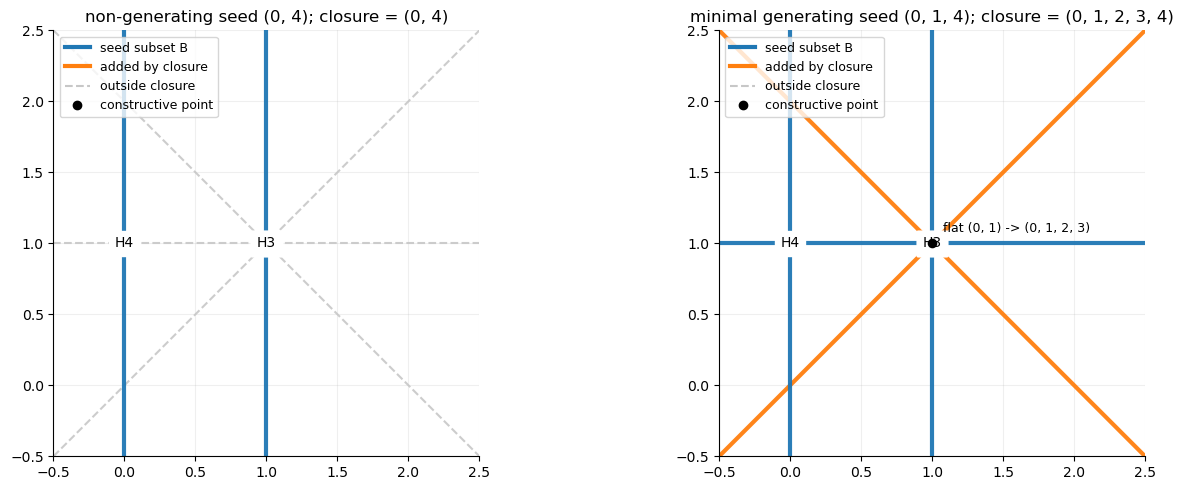

In [ ]:
# Blue lines are the chosen seed subset, orange lines are added by constructive closure, and faint gray lines are not yet in the closure.

bad_seed = (0, 4)
good_seed = seed_indices
bad_closure = A.constructive_closure_indices(bad_seed)
good_closure = A.constructive_closure_indices(good_seed)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
plot_constructive_state(
    A,
    bad_seed,
    ax=axs[0],
    title=f"non-generating seed {bad_seed}; closure = {bad_closure}",
)

plot_constructive_state(
    A,
    good_seed,
    ax=axs[1],
    title=f"minimal generating seed {good_seed}; closure = {good_closure}",
)

plt.tight_layout()
plt.show()